# v7 — Image distortion robustness evaluation (v2 through v6)

Runs each model from v2-v6 on the held-out 241-study test set, both clean and with four image distortions: contrast reduction, motion blur, gaussian noise, and mixed distortion.

**Important**: only the IMAGE channel is distorted — EHR and radiology report text are unchanged. So v6 (which fuses text+image+EHR) is expected to degrade much less than v2/v3/v4 (image+EHR only).

**Outputs** (saved to `results/`):
- `distortion_eval_long.csv`  — one row per (model, distortion) with AUROC / AUPRC / Δ vs clean
- `distortion_eval_wide.csv`  — distortions × models matrix of AUROC
- `distortion_bar_per_distortion.png`  — grouped bar chart
- `distortion_degradation_curves.png`  — per-model degradation line plot
- `distortion_roc_<distortion>.png`    — per-distortion ROC overlays (5 files)

## 1. Imports & device

In [1]:
import os, re, json, copy, time, random, warnings
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from PIL import Image
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')
DEVICE = (
    torch.device('cuda') if torch.cuda.is_available()
    else torch.device('mps') if torch.backends.mps.is_available()
    else torch.device('cpu')
)
warnings.filterwarnings('ignore')
print('device:', DEVICE)

device: mps


## 2. Paths and distortion catalog

In [2]:
PROJ = Path.cwd().parent if Path.cwd().name == 'code' else Path.cwd()
DATA = PROJ / 'data'
RES  = PROJ / 'results'
RES.mkdir(exist_ok=True)

COHORT_CSV = DATA / 'mimic_ed_cxr_pneumonia_multimodal_cohort.csv'
IMG_ROOT   = DATA / 'files'                         # clean images
DIST_ROOT  = DATA / 'distorted_test_files'          # distorted images
REPORTS_ROOT = DATA / 'reports'

# (display label, folder name under DIST_ROOT or None for clean baseline)
DISTORTIONS = [
    ('clean',              None),
    ('contrast_reduction', 'contrast_reduction_s2'),
    ('motion_blur',        'motion_blur_s2'),
    ('gaussian_noise',     'gaussian_noise_s2'),
    ('mixed',              'mixed_distortion'),
]

for label, folder in DISTORTIONS:
    if folder is None:
        print(f'{label:20s}  -> clean (data/files/)')
    else:
        n = len(list((DIST_ROOT / folder).rglob('*.jpg')))
        print(f'{label:20s}  -> {folder}  ({n} jpgs)')

clean                 -> clean (data/files/)
contrast_reduction    -> contrast_reduction_s2  (241 jpgs)
motion_blur           -> motion_blur_s2  (241 jpgs)
gaussian_noise        -> gaussian_noise_s2  (241 jpgs)
mixed                 -> mixed_distortion  (241 jpgs)


## 3. Cohort & test split (matches v3's saved test predictions — 241 studies, all distortion files present)

In [3]:
# Use v3's SAVED test split as the canonical test set.
# This is critical: the distorted images were generated for v3's test studies (241/241 match),
# while train_test_split on the cohort would give a *different* 241.
df_all = pd.read_csv(COHORT_CSV)

V3_PRED_CSV = RES / 'vit_v3_test_predictions.csv'
assert V3_PRED_CSV.exists(), f'Missing {V3_PRED_CSV} — needed to recover the canonical test split.'
v3_pred = pd.read_csv(V3_PRED_CSV)
test_sids = set(v3_pred['study_id'].astype(int).tolist())
print(f'canonical test set: {len(test_sids)} study_ids (from {V3_PRED_CSV.name})')

is_test = df_all['study_id'].astype(int).isin(test_sids)
test_df     = df_all[is_test].reset_index(drop=True)
trainval_df = df_all[~is_test].reset_index(drop=True)

# Keep a train/val split inside trainval (not really used downstream but kept for compat)
train_df, val_df = train_test_split(
    trainval_df, test_size=0.15/0.85, random_state=SEED,
    stratify=trainval_df['Pneumonia']
)
y_test = test_df['Pneumonia'].values.astype(np.float32)
print(f'train/val/test = {len(train_df)}/{len(val_df)}/{len(test_df)}')
print(f'test prevalence = {y_test.mean():.4f}')

# Sanity: every test row must have a matching distorted file
from pathlib import Path as _P
def _check(folder):
    miss = 0
    for _, r in test_df.iterrows():
        sid, sty, did = int(r['subject_id']), int(r['study_id']), r['dicom_id']
        p = DIST_ROOT / folder / f'p{str(sid)[:2]}' / f'p{sid}' / f's{sty}' / f'{did}.jpg'
        if not p.exists(): miss += 1
    return miss
for lbl, folder in DISTORTIONS:
    if folder is None: continue
    m = _check(folder)
    print(f'  {lbl:20s} missing: {m}/{len(test_df)}')


canonical test set: 241 study_ids (from vit_v3_test_predictions.csv)
train/val/test = 1119/241/241
test prevalence = 0.3278
  contrast_reduction   missing: 0/241
  motion_blur          missing: 0/241
  gaussian_noise       missing: 0/241
  mixed                missing: 0/241


## 4. EHR preprocessing
We refit the imputer + scaler on train+val so v5/v6's single-model evaluation matches what they saw at training time.

In [4]:
EHR_COLS = [
    'age','gender','triage_temperature','triage_heartrate','triage_resprate',
    'triage_o2sat','triage_sbp','triage_dbp','triage_acuity',
    'chiefcom_shortness_of_breath','chiefcom_cough','chiefcom_fever_chills',
    'cci_Pulmonary','cci_CHF','score_CCI'
]

def make_ehr(df_sub, scaler=None, imputer=None, fit=False, cols=EHR_COLS):
    X = df_sub[cols].copy()
    # gender already int 0/1 in this cohort; keep as-is
    X = X.apply(pd.to_numeric, errors='coerce')
    if fit:
        imputer = SimpleImputer(strategy='median').fit(X.values)
        Xi = imputer.transform(X.values)
        scaler = StandardScaler().fit(Xi)
    else:
        Xi = imputer.transform(X.values)
    return scaler.transform(Xi).astype(np.float32), scaler, imputer

X_tab_tv, EHR_SCALER, EHR_IMPUTER = make_ehr(trainval_df, fit=True)
X_tab_test, *_                    = make_ehr(test_df, scaler=EHR_SCALER, imputer=EHR_IMPUTER)
print('EHR shapes:', X_tab_tv.shape, X_tab_test.shape)

EHR shapes: (1360, 15) (241, 15)


## 5. Image-path helpers — works for clean OR distorted folder

In [5]:
def build_clean_path(row):
    sid, sty, did = int(row['subject_id']), int(row['study_id']), row['dicom_id']
    return IMG_ROOT / f'p{str(sid)[:2]}' / f'p{sid}' / f's{sty}' / f'{did}.jpg'

def build_distorted_path(row, folder):
    sid, sty, did = int(row['subject_id']), int(row['study_id']), row['dicom_id']
    return DIST_ROOT / folder / f'p{str(sid)[:2]}' / f'p{sid}' / f's{sty}' / f'{did}.jpg'

def path_for(row, dist_folder):
    return build_clean_path(row) if dist_folder is None else build_distorted_path(row, dist_folder)

# Quick sanity check across all distortions on the test set
for label, folder in DISTORTIONS:
    missing = sum(not path_for(r, folder).exists() for _, r in test_df.iterrows())
    print(f'{label:20s}  missing in test set: {missing}/{len(test_df)}')

clean                 missing in test set: 0/241
contrast_reduction    missing in test set: 0/241
motion_blur           missing in test set: 0/241
gaussian_noise        missing in test set: 0/241
mixed                 missing in test set: 0/241


## 6. Model classes (shared with v2/v3/v4)

In [6]:
class TabularMLP(nn.Module):
    def __init__(self, in_dim, out_dim=64, hidden=128, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, out_dim), nn.ReLU(),
        )
    def forward(self, x): return self.net(x)

class MultimodalViTClassifier(nn.Module):
    def __init__(self, vit_backbone, vit_feat_dim, tab_in_dim,
                 tab_out_dim=64, tab_hidden=128, head_hidden=128, dropout=0.2):
        super().__init__()
        self.vit  = vit_backbone
        self.mlp  = TabularMLP(tab_in_dim, out_dim=tab_out_dim,
                               hidden=tab_hidden, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(vit_feat_dim + tab_out_dim, head_hidden), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(head_hidden, 1),
        )
    def forward(self, img, tab):
        f_img = self.vit(img)
        f_tab = self.mlp(tab)
        return self.head(torch.cat([f_img, f_tab], dim=1)).squeeze(-1)


## 7. Build a ViT backbone matching the saved checkpoint

In [7]:
import timm
from torchvision import transforms as T

def build_vit_for(model_name):
    backbone = timm.create_model(model_name, pretrained=False, num_classes=0)
    feat_dim = backbone.num_features
    cfg = backbone.default_cfg
    img_size = cfg['input_size'][-1]
    mean = cfg['mean']; std = cfg['std']
    return backbone, feat_dim, img_size, mean, std

def build_transform(mean, std, img_size):
    return T.Compose([
        T.Resize((img_size, img_size)),
        T.ToTensor(),
        T.Normalize(mean=mean, std=std),
    ])

## 8. Inference dataset + predictor

In [8]:
class ImgTabDataset(Dataset):
    def __init__(self, df, X_tab, dist_folder, transform):
        self.df = df.reset_index(drop=True)
        self.X_tab = X_tab
        self.dist_folder = dist_folder
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(path_for(row, self.dist_folder)).convert('RGB')
        return self.transform(img), torch.from_numpy(self.X_tab[i])

@torch.no_grad()
def predict_vit_model(model, df, X_tab, dist_folder, transform, batch=16):
    ds = ImgTabDataset(df, X_tab, dist_folder, transform)
    dl = DataLoader(ds, batch_size=batch, shuffle=False, num_workers=0)
    model.eval()
    probs = np.zeros(len(ds), dtype=np.float32)
    i = 0
    for img, tab in dl:
        img = img.to(DEVICE); tab = tab.to(DEVICE)
        logit = model(img, tab)
        b = logit.size(0)
        probs[i:i+b] = torch.sigmoid(logit).cpu().numpy()
        i += b
    return probs

## 9. Evaluate v2 / v3 / v4_swa across distortions

In [9]:
def _infer_arch_from_state(state, vit_feat_dim, tab_in_dim):
    """Recover (tab_hidden, tab_out_dim, head_hidden) from a saved state_dict
    so the loader works with any v2/v3/v4 head-size combo (128 / 256)."""
    tab_hidden  = state['mlp.net.0.weight'].shape[0]
    tab_out_dim = state['mlp.net.3.weight'].shape[0]
    head_hidden = state['head.0.weight'].shape[0]
    fused_in    = state['head.0.weight'].shape[1]
    assert fused_in == vit_feat_dim + tab_out_dim, (
        f'Backbone mismatch: head.0 expects fused_in={fused_in} but '
        f'vit_feat_dim+tab_out_dim={vit_feat_dim+tab_out_dim}')
    return tab_hidden, tab_out_dim, head_hidden

def load_vit_checkpoint(ckpt_path):
    d = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    name = d.get('model_name', 'vit_base_patch16_224')
    backbone, feat_dim, img_size, mean, std = build_vit_for(name)
    mean = d.get('img_mean', mean); std = d.get('img_std', std)
    img_size = d.get('img_size', img_size)

    state = d.get('state_dict', d)
    tab_hidden, tab_out_dim, head_hidden = _infer_arch_from_state(
        state, vit_feat_dim=feat_dim, tab_in_dim=X_tab_tv.shape[1]
    )
    print(f'   inferred arch: tab_hidden={tab_hidden}  tab_out_dim={tab_out_dim}  head_hidden={head_hidden}')

    model = MultimodalViTClassifier(
        backbone, feat_dim,
        tab_in_dim=X_tab_tv.shape[1],
        tab_out_dim=tab_out_dim,
        tab_hidden=tab_hidden,
        head_hidden=head_hidden,
    )
    model.load_state_dict(state, strict=True)
    model = model.to(DEVICE).eval()
    transform = build_transform(mean, std, img_size)
    return model, transform, name

results = []   # accumulate (model, distortion, AUROC, AUPRC, n)
predictions = {}  # (model, distortion) -> prob array (for ROC plotting)

for ckpt_label, ckpt_file in [('v2', 'vit_v2_best.pt'),
                              ('v3', 'vit_v3_best.pt'),
                              ('v4_swa', 'vit_v4_swa_best.pt')]:
    p = RES / ckpt_file
    if not p.exists():
        print(f'!! {ckpt_label} checkpoint missing at {p} — skipping')
        continue
    print(f'--- {ckpt_label} ---')
    model, transform, name = load_vit_checkpoint(p)
    print(f'   backbone={name}')
    for dlabel, folder in DISTORTIONS:
        t0 = time.time()
        probs = predict_vit_model(model, test_df, X_tab_test, folder, transform)
        a = roc_auc_score(y_test, probs)
        ap = average_precision_score(y_test, probs)
        results.append({'model': ckpt_label, 'distortion': dlabel,
                        'AUROC': a, 'AUPRC': ap, 'n_test': len(y_test)})
        predictions[(ckpt_label, dlabel)] = probs
        print(f'   {dlabel:20s} AUROC={a:.4f} AUPRC={ap:.4f}  ({time.time()-t0:.1f}s)')
    del model
    if DEVICE.type == 'cuda': torch.cuda.empty_cache()


--- v2 ---
   inferred arch: tab_hidden=128  tab_out_dim=64  head_hidden=128
   backbone=vit_base_patch16_224
   clean                AUROC=0.7121 AUPRC=0.6067  (7.9s)
   contrast_reduction   AUROC=0.6760 AUPRC=0.5602  (7.2s)
   motion_blur          AUROC=0.7064 AUPRC=0.6091  (6.2s)
   gaussian_noise       AUROC=0.7074 AUPRC=0.6044  (11.1s)
   mixed                AUROC=0.6997 AUPRC=0.5839  (8.3s)
--- v3 ---
   inferred arch: tab_hidden=128  tab_out_dim=64  head_hidden=256
   backbone=vit_base_patch16_384.augreg_in21k_ft_in1k
   clean                AUROC=0.7483 AUPRC=0.6214  (13.1s)
   contrast_reduction   AUROC=0.7259 AUPRC=0.5847  (12.4s)
   motion_blur          AUROC=0.7473 AUPRC=0.6111  (11.5s)
   gaussian_noise       AUROC=0.7465 AUPRC=0.6201  (16.3s)
   mixed                AUROC=0.7415 AUPRC=0.6139  (13.7s)
--- v4_swa ---
   inferred arch: tab_hidden=128  tab_out_dim=64  head_hidden=256
   backbone=vit_base_patch16_384.augreg_in21k_ft_in1k
   clean                AUROC=0.7415 A

## 10. v5 — XRV DenseNet121 + EHR (single model, train on full train+val)
We train a fresh single fusion model (no CV) so it's directly comparable to v2/v3/v4.

In [10]:
import torchxrayvision as xrv
from torchvision import transforms as T2

XRV_WEIGHTS = 'densenet121-res224-all'
PNEU_IDX = xrv.datasets.default_pathologies.index('Pneumonia')

class XRVTransform:
    def __init__(self, size=224):
        self.size = size
        self.tx = T2.Compose([T2.Resize((size, size)), T2.Grayscale(num_output_channels=1)])
    def __call__(self, img_path):
        img = Image.open(img_path).convert('RGB')
        img = self.tx(img)
        arr = np.array(img, dtype=np.float32)
        arr = (arr / 255.0) * 2048.0 - 1024.0
        return torch.from_numpy(arr[None, :, :])

xrv_tx = XRVTransform(224)

class XRVImageDataset(Dataset):
    def __init__(self, df, dist_folder):
        self.df = df.reset_index(drop=True); self.dist_folder = dist_folder
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        return xrv_tx(path_for(self.df.iloc[i], self.dist_folder))

class XRVFusion(nn.Module):
    def __init__(self, tab_in, feat_dim=1024, tab_out=64, hidden=128, dropout=0.3):
        super().__init__()
        self.tab = nn.Sequential(
            nn.Linear(tab_in, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, tab_out), nn.ReLU(),
        )
        self.head = nn.Sequential(
            nn.Linear(feat_dim + tab_out, hidden), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(hidden, 1),
        )
    def forward(self, img_feat, tab):
        return self.head(torch.cat([img_feat, self.tab(tab)], dim=1)).squeeze(-1)

In [11]:
# ---- 10.1 XRV feature extractor (frozen) -- compute features once per (split, distortion) ----
xrv_model = xrv.models.DenseNet(weights=XRV_WEIGHTS).to(DEVICE).eval()
for p in xrv_model.parameters():
    p.requires_grad = False

@torch.no_grad()
def extract_xrv_feats(df, dist_folder, batch=32):
    dl = DataLoader(XRVImageDataset(df, dist_folder), batch_size=batch,
                    shuffle=False, num_workers=0)
    feats = np.zeros((len(df), 1024), dtype=np.float32)
    priors = np.zeros(len(df), dtype=np.float32)
    i = 0
    for batch_imgs in dl:
        batch_imgs = batch_imgs.to(DEVICE)
        f = xrv_model.features2(batch_imgs)
        logits = xrv_model.classifier(f)
        b = batch_imgs.size(0)
        feats[i:i+b] = f.cpu().numpy()
        priors[i:i+b] = torch.sigmoid(logits[:, PNEU_IDX]).cpu().numpy()
        i += b
    return feats, priors

# Train+val features come from CLEAN images and are cached if the v6 cache exists.
V6_CACHE = RES / 'v6_xrv_feat_and_prior.npz'
if V6_CACHE.exists():
    z = np.load(V6_CACHE)
    cache_feats, cache_priors, cache_ids = z['X'], z['prior'], z['ids']
    id_to_idx = {int(s): i for i, s in enumerate(cache_ids)}
    sids = trainval_df['study_id'].astype(int).values
    if all(int(s) in id_to_idx for s in sids):
        xrv_feat_tv = np.stack([cache_feats[id_to_idx[int(s)]] for s in sids]).astype(np.float32)
        xrv_prior_tv = np.array([cache_priors[id_to_idx[int(s)]] for s in sids], dtype=np.float32)
        print('XRV trainval features loaded from v6 cache:', xrv_feat_tv.shape)
    else:
        print('cache miss for some trainval; recomputing'); xrv_feat_tv = None
else:
    xrv_feat_tv = None
if xrv_feat_tv is None:
    t0 = time.time()
    xrv_feat_tv, xrv_prior_tv = extract_xrv_feats(trainval_df, dist_folder=None)
    print(f'extracted XRV features for {len(trainval_df)} trainval rows in {time.time()-t0:.1f}s')

XRV trainval features loaded from v6 cache: (1360, 1024)


In [12]:
# ---- 10.2 Train a single v5 fusion model on full train+val ----
torch.manual_seed(SEED)
v5_model = XRVFusion(tab_in=X_tab_tv.shape[1]).to(DEVICE)
y_tv = trainval_df['Pneumonia'].values.astype(np.float32)
pos = y_tv.sum(); neg = len(y_tv) - pos
pw = torch.tensor(max(neg, 1) / max(pos, 1), device=DEVICE)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pw)
opt = torch.optim.AdamW(v5_model.parameters(), lr=3e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=20)

f_tv_t = torch.from_numpy(xrv_feat_tv).to(DEVICE)
x_tv_t = torch.from_numpy(X_tab_tv).to(DEVICE)
y_tv_t = torch.from_numpy(y_tv).to(DEVICE)

for ep in range(20):
    v5_model.train()
    perm = torch.randperm(len(y_tv), device=DEVICE)
    for s in range(0, len(y_tv), 64):
        idx = perm[s:s+64]
        opt.zero_grad()
        out = v5_model(f_tv_t[idx], x_tv_t[idx])
        loss = loss_fn(out, y_tv_t[idx])
        loss.backward(); opt.step()
    sched.step()
print('v5 single-model training done')

v5 single-model training done


In [13]:
# ---- 10.3 Predict v5 on each distortion ----
v5_model.eval()
for dlabel, folder in DISTORTIONS:
    t0 = time.time()
    feats_te, prior_te = extract_xrv_feats(test_df, folder)
    with torch.no_grad():
        f_te_t = torch.from_numpy(feats_te).to(DEVICE)
        x_te_t = torch.from_numpy(X_tab_test).to(DEVICE)
        probs = torch.sigmoid(v5_model(f_te_t, x_te_t)).cpu().numpy()
    a  = roc_auc_score(y_test, probs)
    ap = average_precision_score(y_test, probs)
    results.append({'model':'v5','distortion':dlabel,
                    'AUROC':a,'AUPRC':ap,'n_test':len(y_test)})
    predictions[('v5', dlabel)] = probs
    print(f'   {dlabel:20s} AUROC={a:.4f} AUPRC={ap:.4f}  ({time.time()-t0:.1f}s)')

   clean                AUROC=0.7415 AUPRC=0.6049  (7.4s)
   contrast_reduction   AUROC=0.7193 AUPRC=0.5643  (6.3s)
   motion_blur          AUROC=0.7411 AUPRC=0.6067  (5.1s)
   gaussian_noise       AUROC=0.7345 AUPRC=0.5974  (9.9s)
   mixed                AUROC=0.7350 AUPRC=0.5977  (7.1s)


## 11. v6 — text + image + EHR (single fusion head, full train+val)
Text features come from the radiology reports (NOT distorted), image features come from the corresponding distorted XRV pass, EHR is unchanged.

In [14]:
from transformers import AutoTokenizer, AutoModel
TEXT_MODEL_ID = 'emilyalsentzer/Bio_ClinicalBERT'
TEXT_MAX_LEN = 256
TEXT_EMB_PATH = RES / 'v6_text_cls_embeddings.npz'
REPORT_CACHE  = RES / 'mimic_cxr_reports_cohort.csv'

if TEXT_EMB_PATH.exists():
    z = np.load(TEXT_EMB_PATH, allow_pickle=True)
    text_feats_all, text_ids_all = z['X'], z['ids']
    text_idx = {int(s): i for i, s in enumerate(text_ids_all)}
    print('text embeddings loaded from cache:', text_feats_all.shape)
else:
    raise RuntimeError('Run vit_v6_text.ipynb first to build the text-embedding cache.')

TEXT_DIM = text_feats_all.shape[1]

def text_for(df_sub):
    return np.stack([text_feats_all[text_idx[int(s)]] for s in df_sub['study_id'].astype(int)]).astype(np.float32)

txt_tv  = text_for(trainval_df)
txt_te  = text_for(test_df)
print('text feats:', txt_tv.shape, txt_te.shape)

text embeddings loaded from cache: (1601, 768)
text feats: (1360, 768) (241, 768)


In [15]:
# ---- 11.1 v6 trimodal fusion head (same architecture as v6 notebook) ----
class TrimodalHead(nn.Module):
    def __init__(self, text_dim=768, img_dim=1024, ehr_dim=15,
                 ehr_hidden=128, ehr_out=64, head_hidden=256, dropout=0.3):
        super().__init__()
        self.ehr = nn.Sequential(
            nn.Linear(ehr_dim, ehr_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(ehr_hidden, ehr_out), nn.ReLU(),
        )
        self.text_proj = nn.Sequential(nn.Linear(text_dim, 256), nn.ReLU(), nn.Dropout(dropout))
        self.img_proj  = nn.Sequential(nn.Linear(img_dim, 256), nn.ReLU(), nn.Dropout(dropout))
        self.head = nn.Sequential(
            nn.Linear(256+256+ehr_out, head_hidden), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(head_hidden, 1),
        )
    def forward(self, t, i, e):
        return self.head(torch.cat([self.text_proj(t), self.img_proj(i), self.ehr(e)],
                                    dim=1)).squeeze(-1)

torch.manual_seed(SEED)
v6_head = TrimodalHead(text_dim=TEXT_DIM, img_dim=1024,
                       ehr_dim=X_tab_tv.shape[1]).to(DEVICE)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pw)
opt = torch.optim.AdamW(v6_head.parameters(), lr=3e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=25)

T_tv_t = torch.from_numpy(txt_tv).to(DEVICE)
I_tv_t = torch.from_numpy(xrv_feat_tv).to(DEVICE)
E_tv_t = torch.from_numpy(X_tab_tv).to(DEVICE)
y_tv_t = torch.from_numpy(y_tv).to(DEVICE)

for ep in range(25):
    v6_head.train()
    perm = torch.randperm(len(y_tv), device=DEVICE)
    for s in range(0, len(y_tv), 64):
        idx = perm[s:s+64]
        opt.zero_grad()
        out = v6_head(T_tv_t[idx], I_tv_t[idx], E_tv_t[idx])
        loss_fn(out, y_tv_t[idx]).backward(); opt.step()
    sched.step()
print('v6 single-head training done')

v6 single-head training done


In [16]:
# ---- 11.2 Predict v6 on each distortion (re-extract image feats per distortion) ----
v6_head.eval()
T_te_t = torch.from_numpy(txt_te).to(DEVICE)
E_te_t = torch.from_numpy(X_tab_test).to(DEVICE)
for dlabel, folder in DISTORTIONS:
    t0 = time.time()
    feats_te, _ = extract_xrv_feats(test_df, folder)
    with torch.no_grad():
        I_te_t = torch.from_numpy(feats_te).to(DEVICE)
        probs = torch.sigmoid(v6_head(T_te_t, I_te_t, E_te_t)).cpu().numpy()
    a  = roc_auc_score(y_test, probs)
    ap = average_precision_score(y_test, probs)
    results.append({'model':'v6','distortion':dlabel,
                    'AUROC':a,'AUPRC':ap,'n_test':len(y_test)})
    predictions[('v6', dlabel)] = probs
    print(f'   {dlabel:20s} AUROC={a:.4f} AUPRC={ap:.4f}  ({time.time()-t0:.1f}s)')

   clean                AUROC=0.9019 AUPRC=0.8228  (6.6s)
   contrast_reduction   AUROC=0.8999 AUPRC=0.8062  (6.1s)
   motion_blur          AUROC=0.9011 AUPRC=0.8190  (4.9s)
   gaussian_noise       AUROC=0.9018 AUPRC=0.8218  (9.9s)
   mixed                AUROC=0.8975 AUPRC=0.8125  (7.1s)


## 12. Compile leaderboard

In [17]:
long_df = pd.DataFrame(results)
# Add Δ vs clean column
clean_auroc = long_df[long_df['distortion'] == 'clean'].set_index('model')['AUROC']
long_df['delta_AUROC_vs_clean'] = long_df.apply(
    lambda r: r['AUROC'] - clean_auroc.get(r['model'], np.nan), axis=1
)
long_df = long_df[['model','distortion','AUROC','AUPRC','delta_AUROC_vs_clean','n_test']]
long_df.to_csv(RES / 'distortion_eval_long.csv', index=False)
print(long_df.to_string(index=False))

wide = long_df.pivot(index='distortion', columns='model', values='AUROC')
# Reorder rows so 'clean' is on top
row_order = [d for d, _ in DISTORTIONS]
wide = wide.reindex(row_order)
wide.to_csv(RES / 'distortion_eval_wide.csv')
print('\n=== AUROC matrix (rows=distortion, cols=model) ===')
print(wide.round(4).to_string())

 model         distortion    AUROC    AUPRC  delta_AUROC_vs_clean  n_test
    v2              clean 0.712064 0.606730              0.000000     241
    v2 contrast_reduction 0.675965 0.560159             -0.036099     241
    v2        motion_blur 0.706360 0.609097             -0.005704     241
    v2     gaussian_noise 0.707376 0.604446             -0.004688     241
    v2              mixed 0.699719 0.583939             -0.012346     241
    v3              clean 0.748320 0.621397              0.000000     241
    v3 contrast_reduction 0.725895 0.584723             -0.022425     241
    v3        motion_blur 0.747304 0.611123             -0.001016     241
    v3     gaussian_noise 0.746523 0.620058             -0.001797     241
    v3              mixed 0.741522 0.613919             -0.006798     241
v4_swa              clean 0.741522 0.621953              0.000000     241
v4_swa contrast_reduction 0.732068 0.611543             -0.009455     241
v4_swa        motion_blur 0.747929 0.6

## 13. Plots

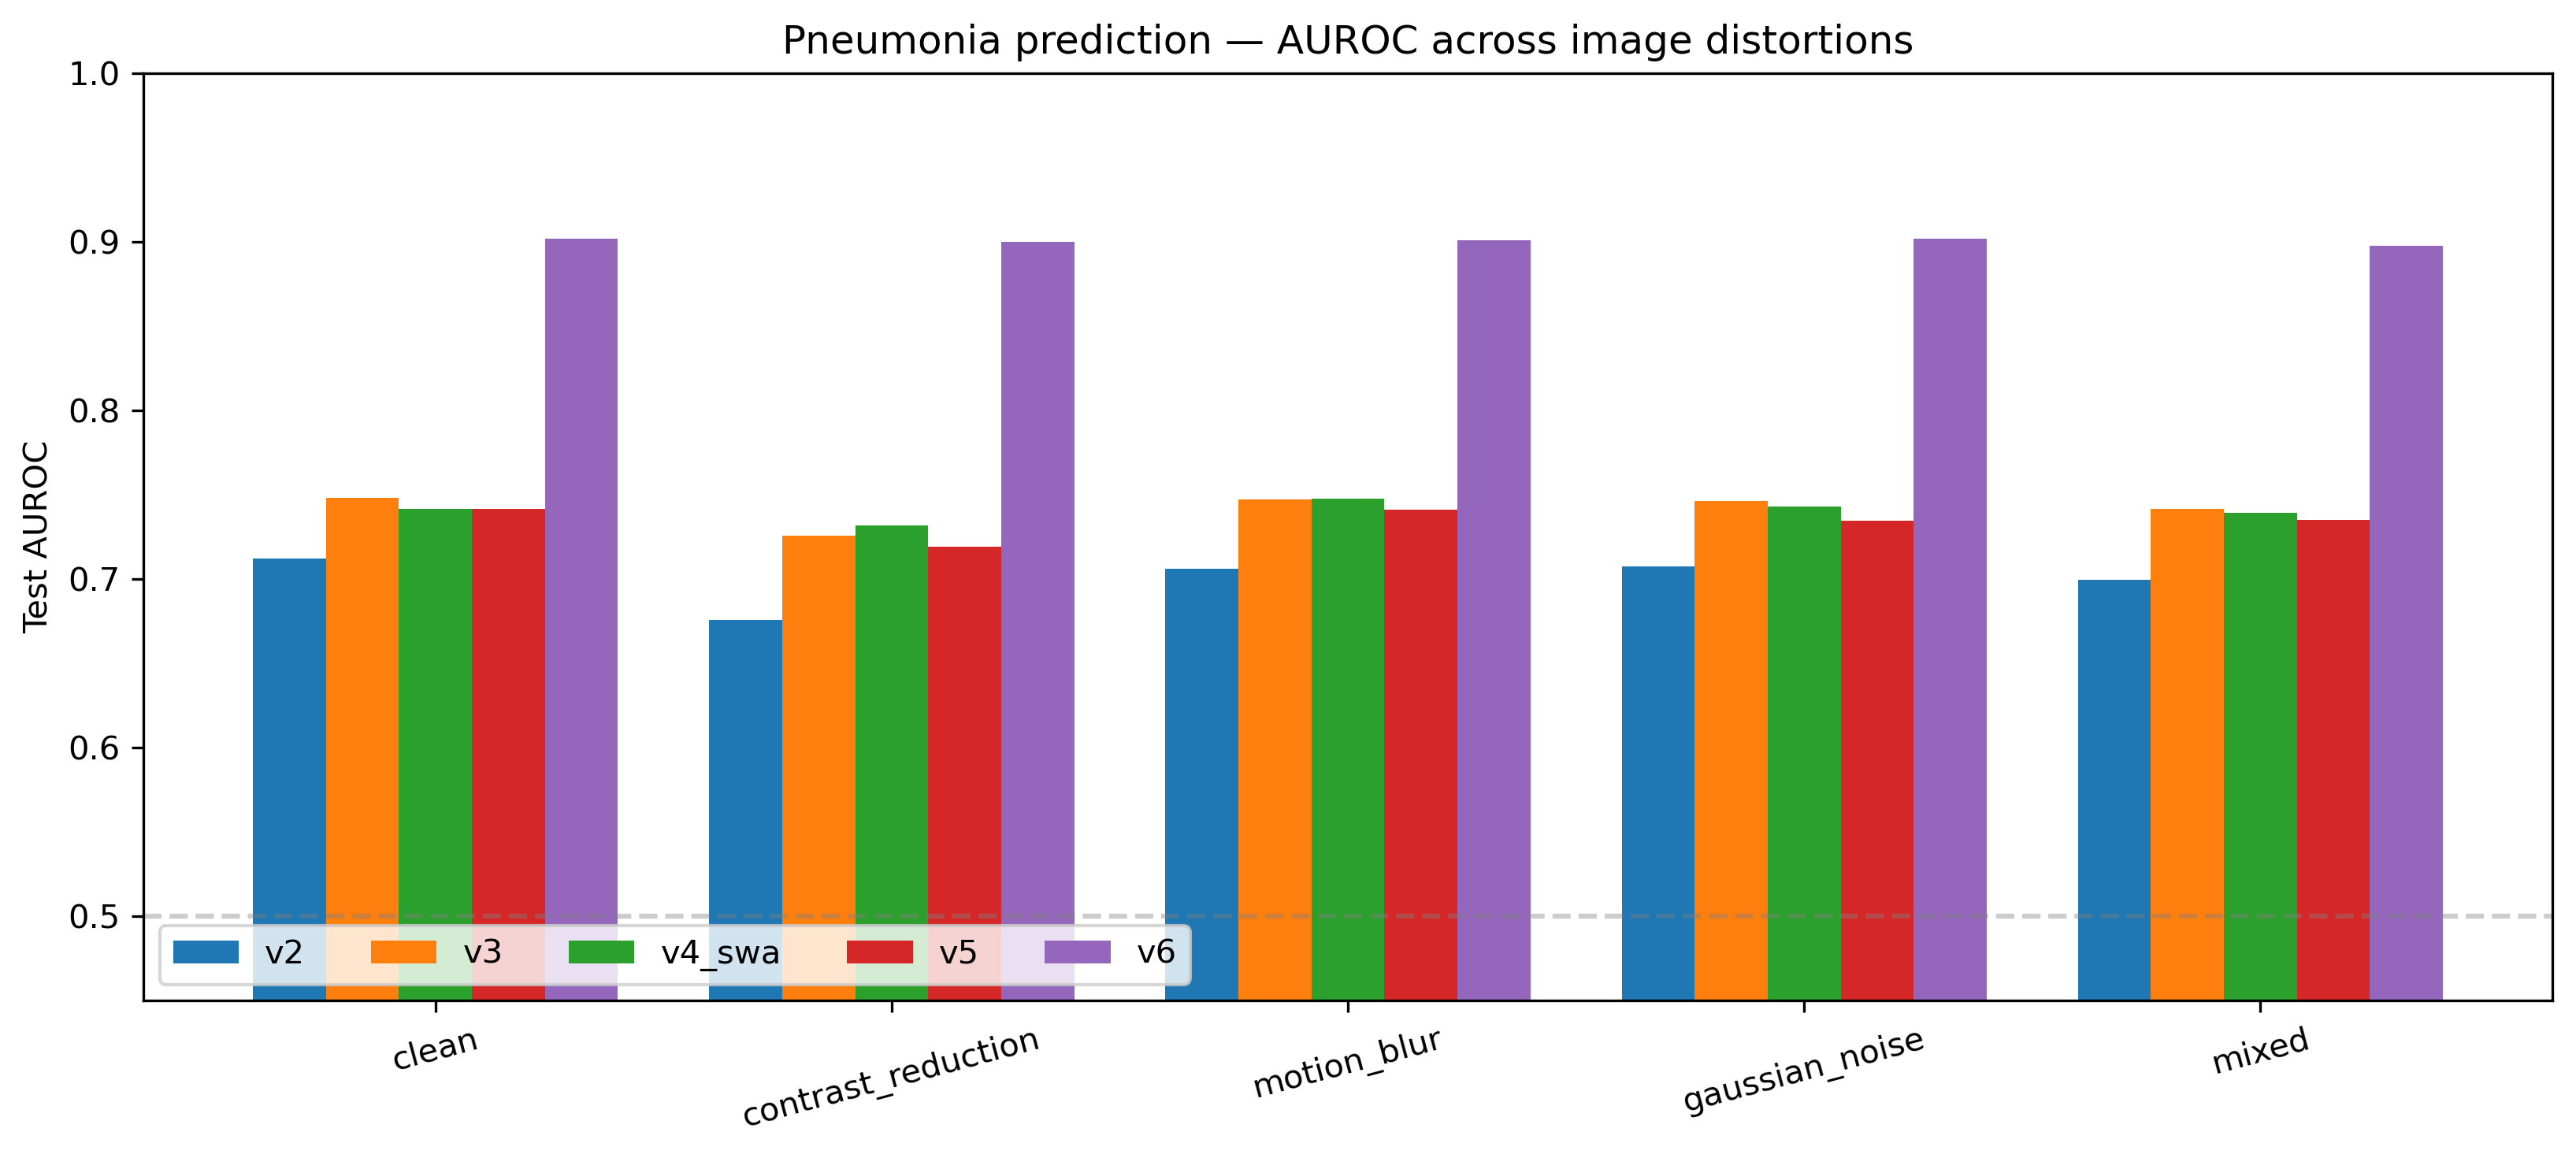

In [18]:
# ---- 13.1 Grouped bar: per-distortion AUROC across models ----
MODELS_ORDER = [m for m in ['v2','v3','v4_swa','v5','v6'] if m in long_df['model'].unique()]
DISTS_ORDER  = [d for d,_ in DISTORTIONS]

fig, ax = plt.subplots(figsize=(11, 5), dpi=300)
x = np.arange(len(DISTS_ORDER))
w = 0.8 / max(len(MODELS_ORDER), 1)
for i, m in enumerate(MODELS_ORDER):
    sub = long_df[long_df['model']==m].set_index('distortion')['AUROC']
    vals = [sub.get(d, np.nan) for d in DISTS_ORDER]
    ax.bar(x + i*w - 0.4 + w/2, vals, w, label=m)
ax.set_xticks(x); ax.set_xticklabels(DISTS_ORDER, rotation=15)
ax.axhline(0.5, color='gray', ls='--', alpha=0.4)
ax.set_ylim(0.45, 1.0); ax.set_ylabel('Test AUROC')
ax.set_title('Pneumonia prediction — AUROC across image distortions')
ax.legend(loc='lower left', ncol=len(MODELS_ORDER))
plt.tight_layout()
plt.savefig(RES / 'distortion_bar_per_distortion.png', dpi=300)
plt.show()

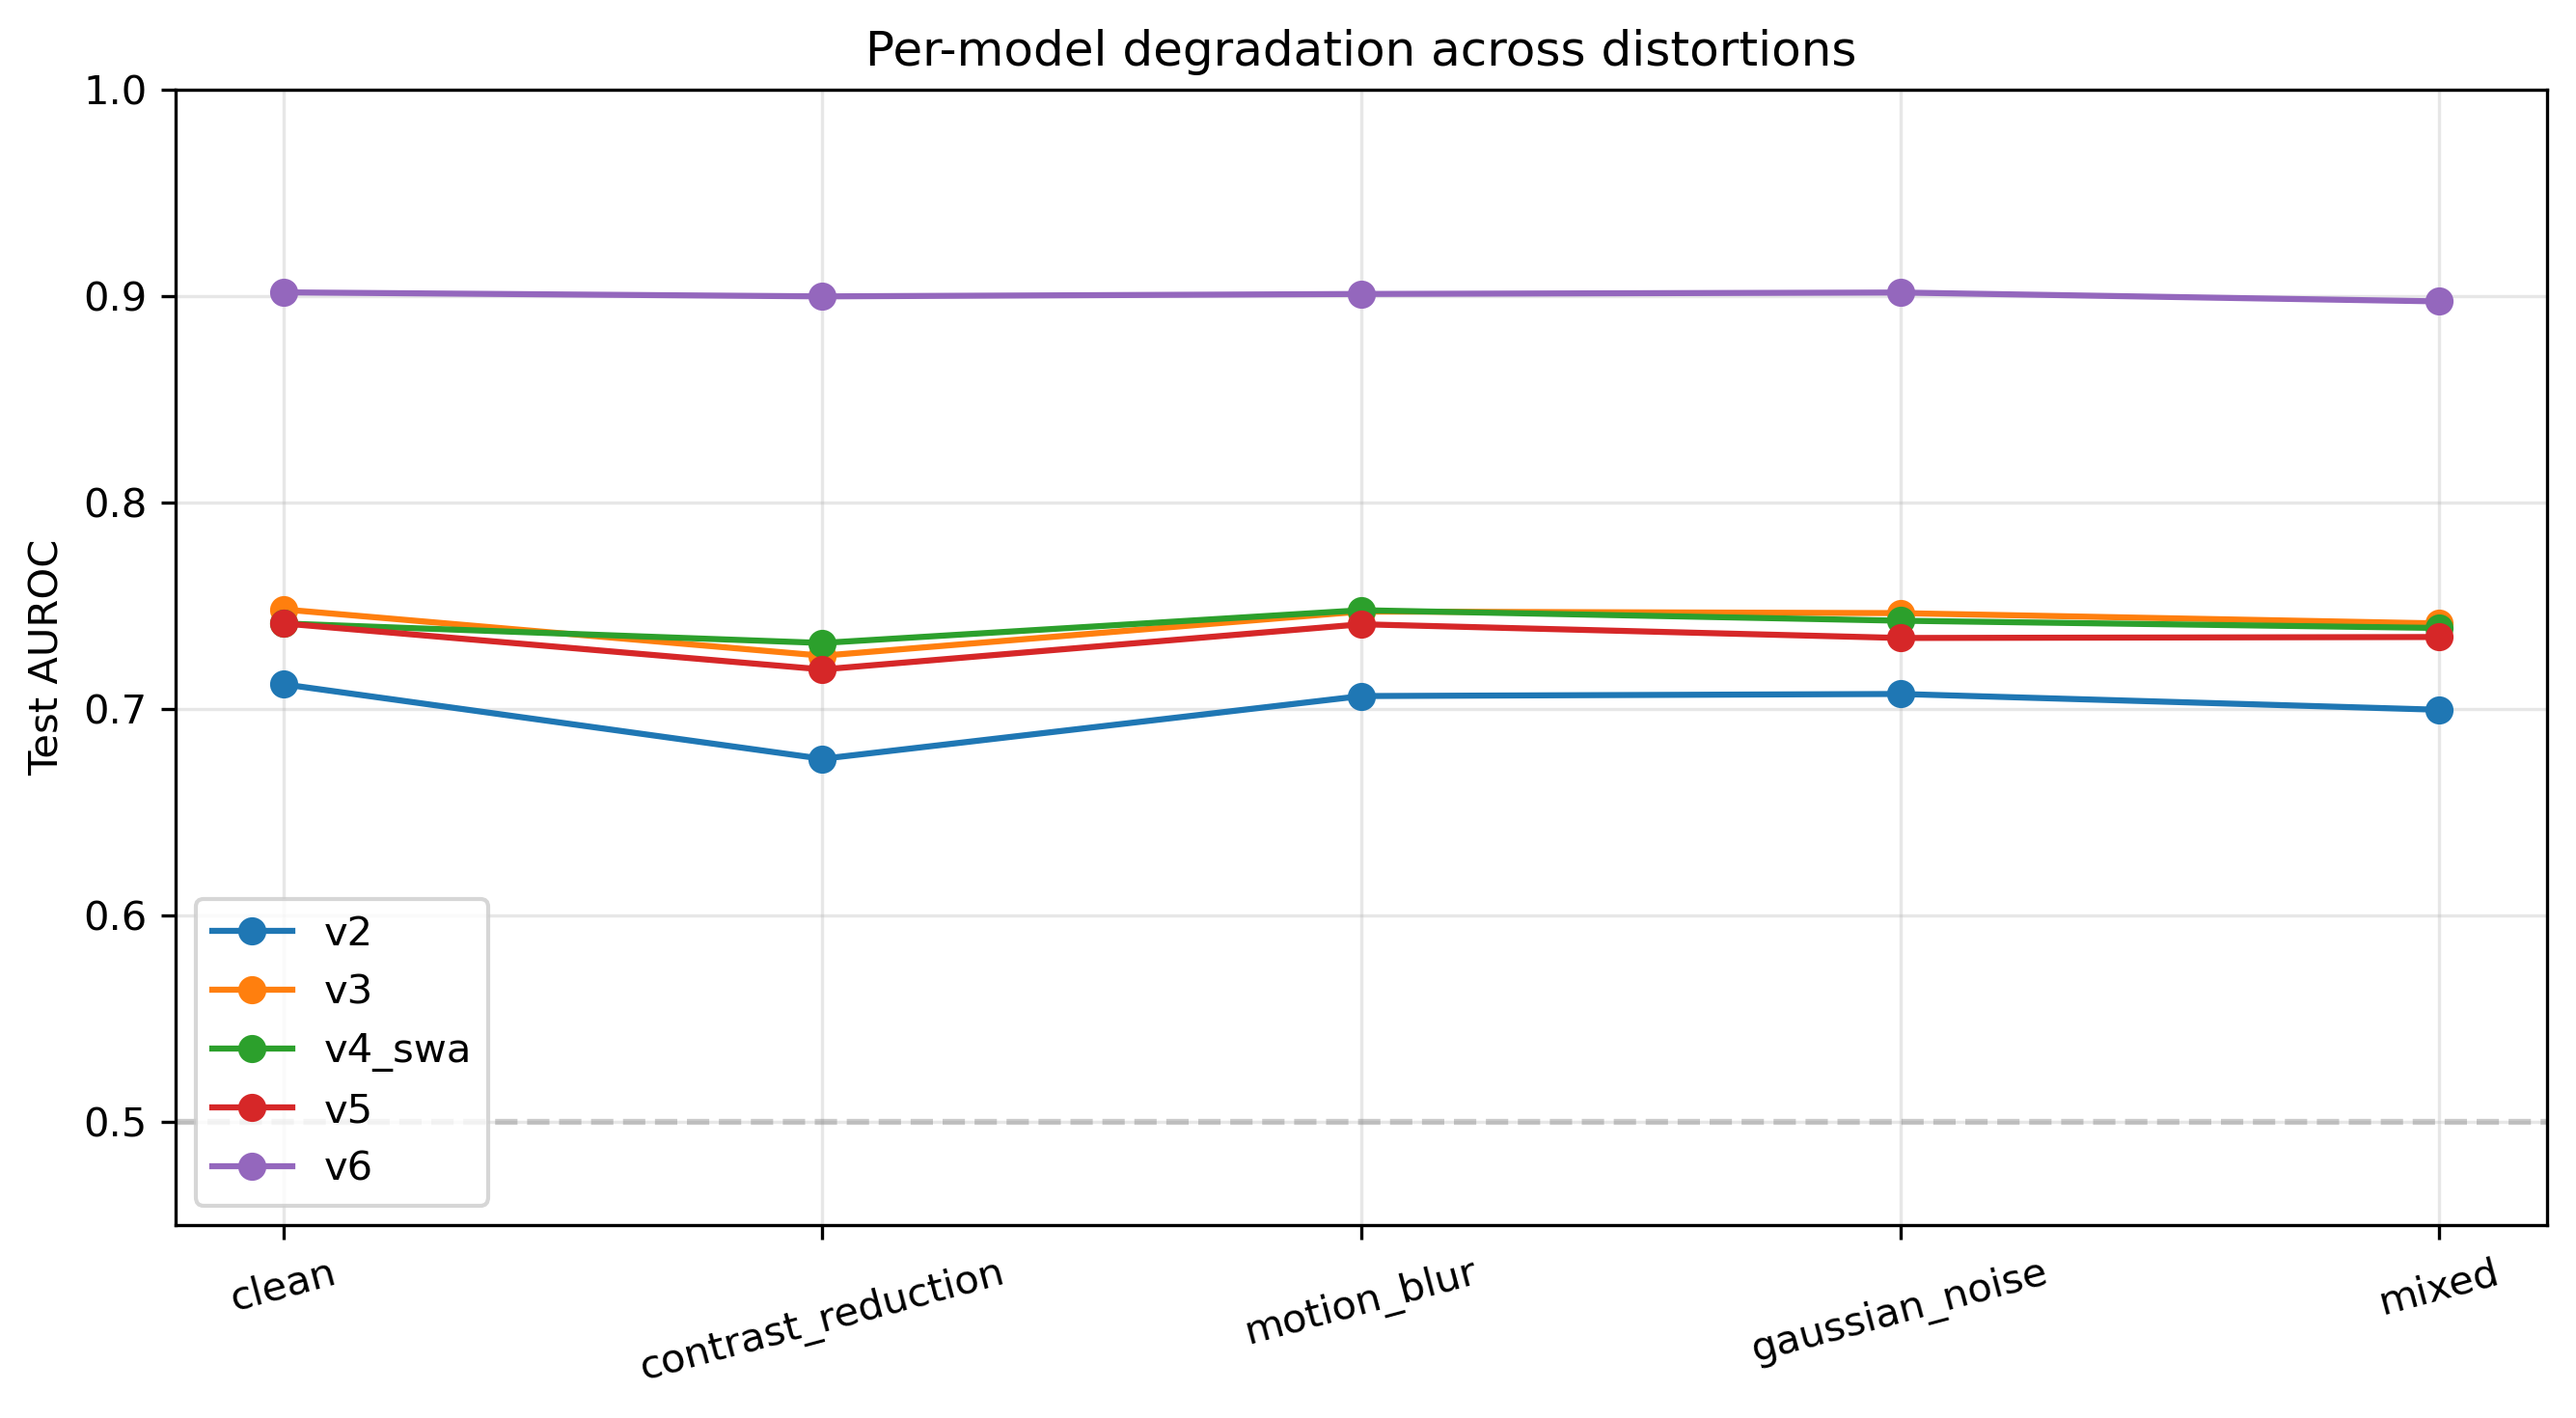

In [19]:
# ---- 13.2 Per-model degradation curves (relative to clean) ----
fig, ax = plt.subplots(figsize=(9, 5), dpi=300)
for m in MODELS_ORDER:
    sub = long_df[long_df['model']==m].set_index('distortion')
    vals = [sub['AUROC'].get(d, np.nan) for d in DISTS_ORDER]
    ax.plot(DISTS_ORDER, vals, marker='o', label=m)
ax.set_ylabel('Test AUROC'); ax.set_title('Per-model degradation across distortions')
ax.set_ylim(0.45, 1.0); ax.axhline(0.5, color='gray', ls='--', alpha=0.4)
ax.grid(alpha=0.3)
plt.xticks(rotation=15)
ax.legend()
plt.tight_layout()
plt.savefig(RES / 'distortion_degradation_curves.png', dpi=300)
plt.show()

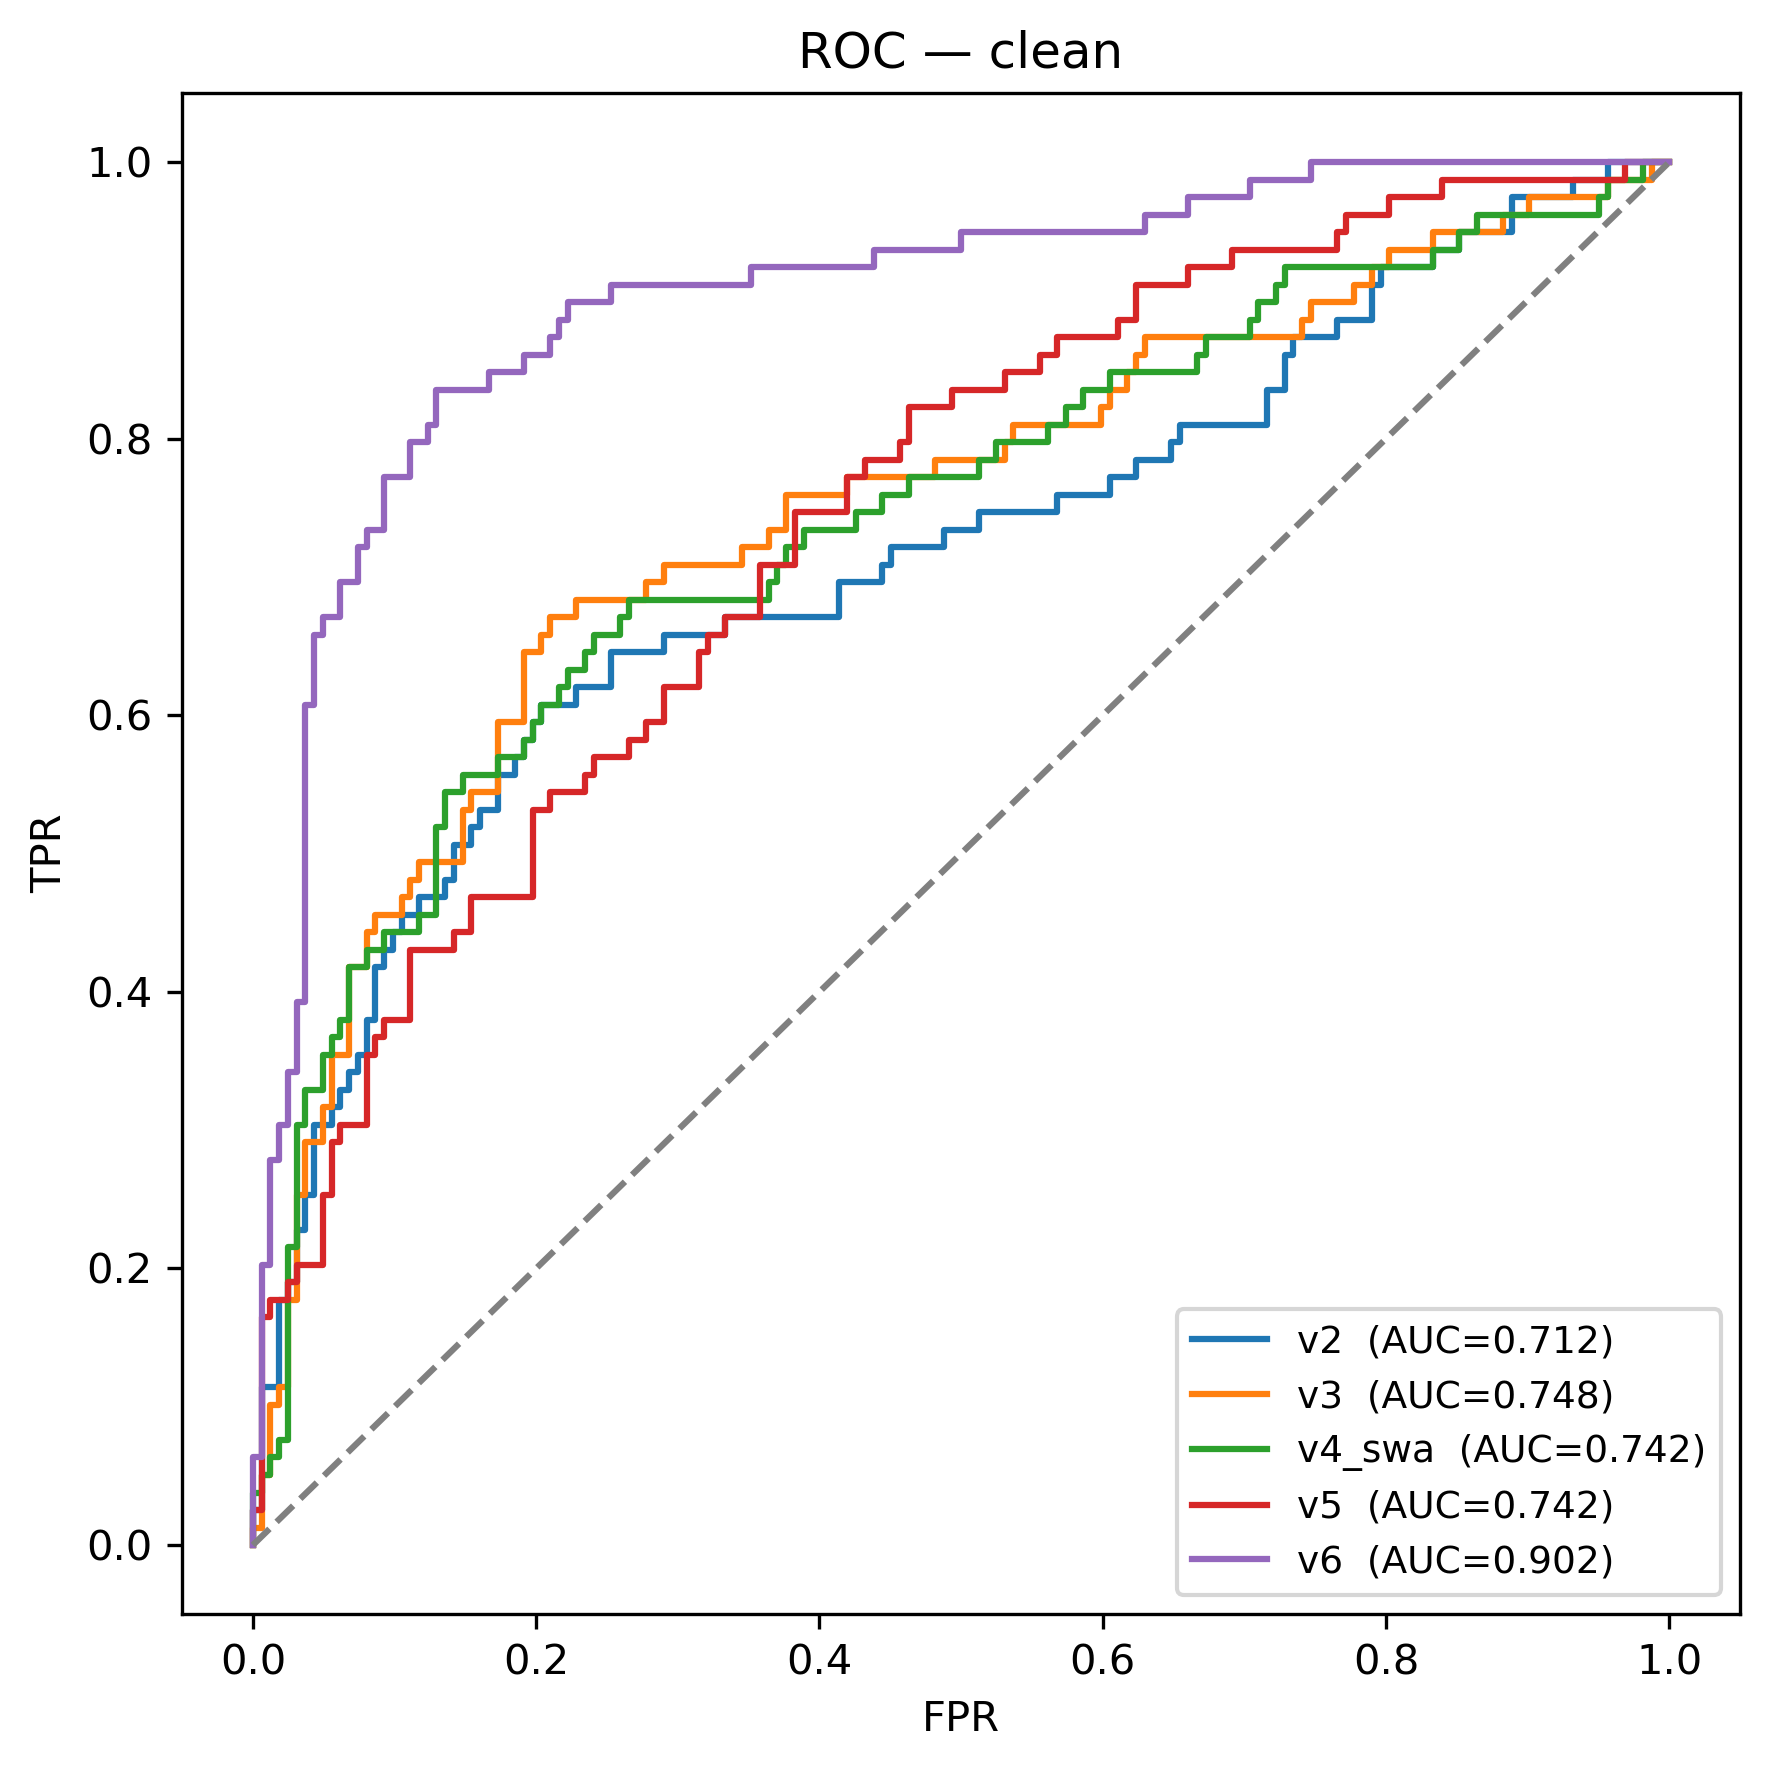

saved: /Users/yj/Library/Mobile Documents/com~apple~CloudDocs/01_Academics_UMN/2026_Spring/CSCI 5527/final_proj/results/distortion_roc_clean.png


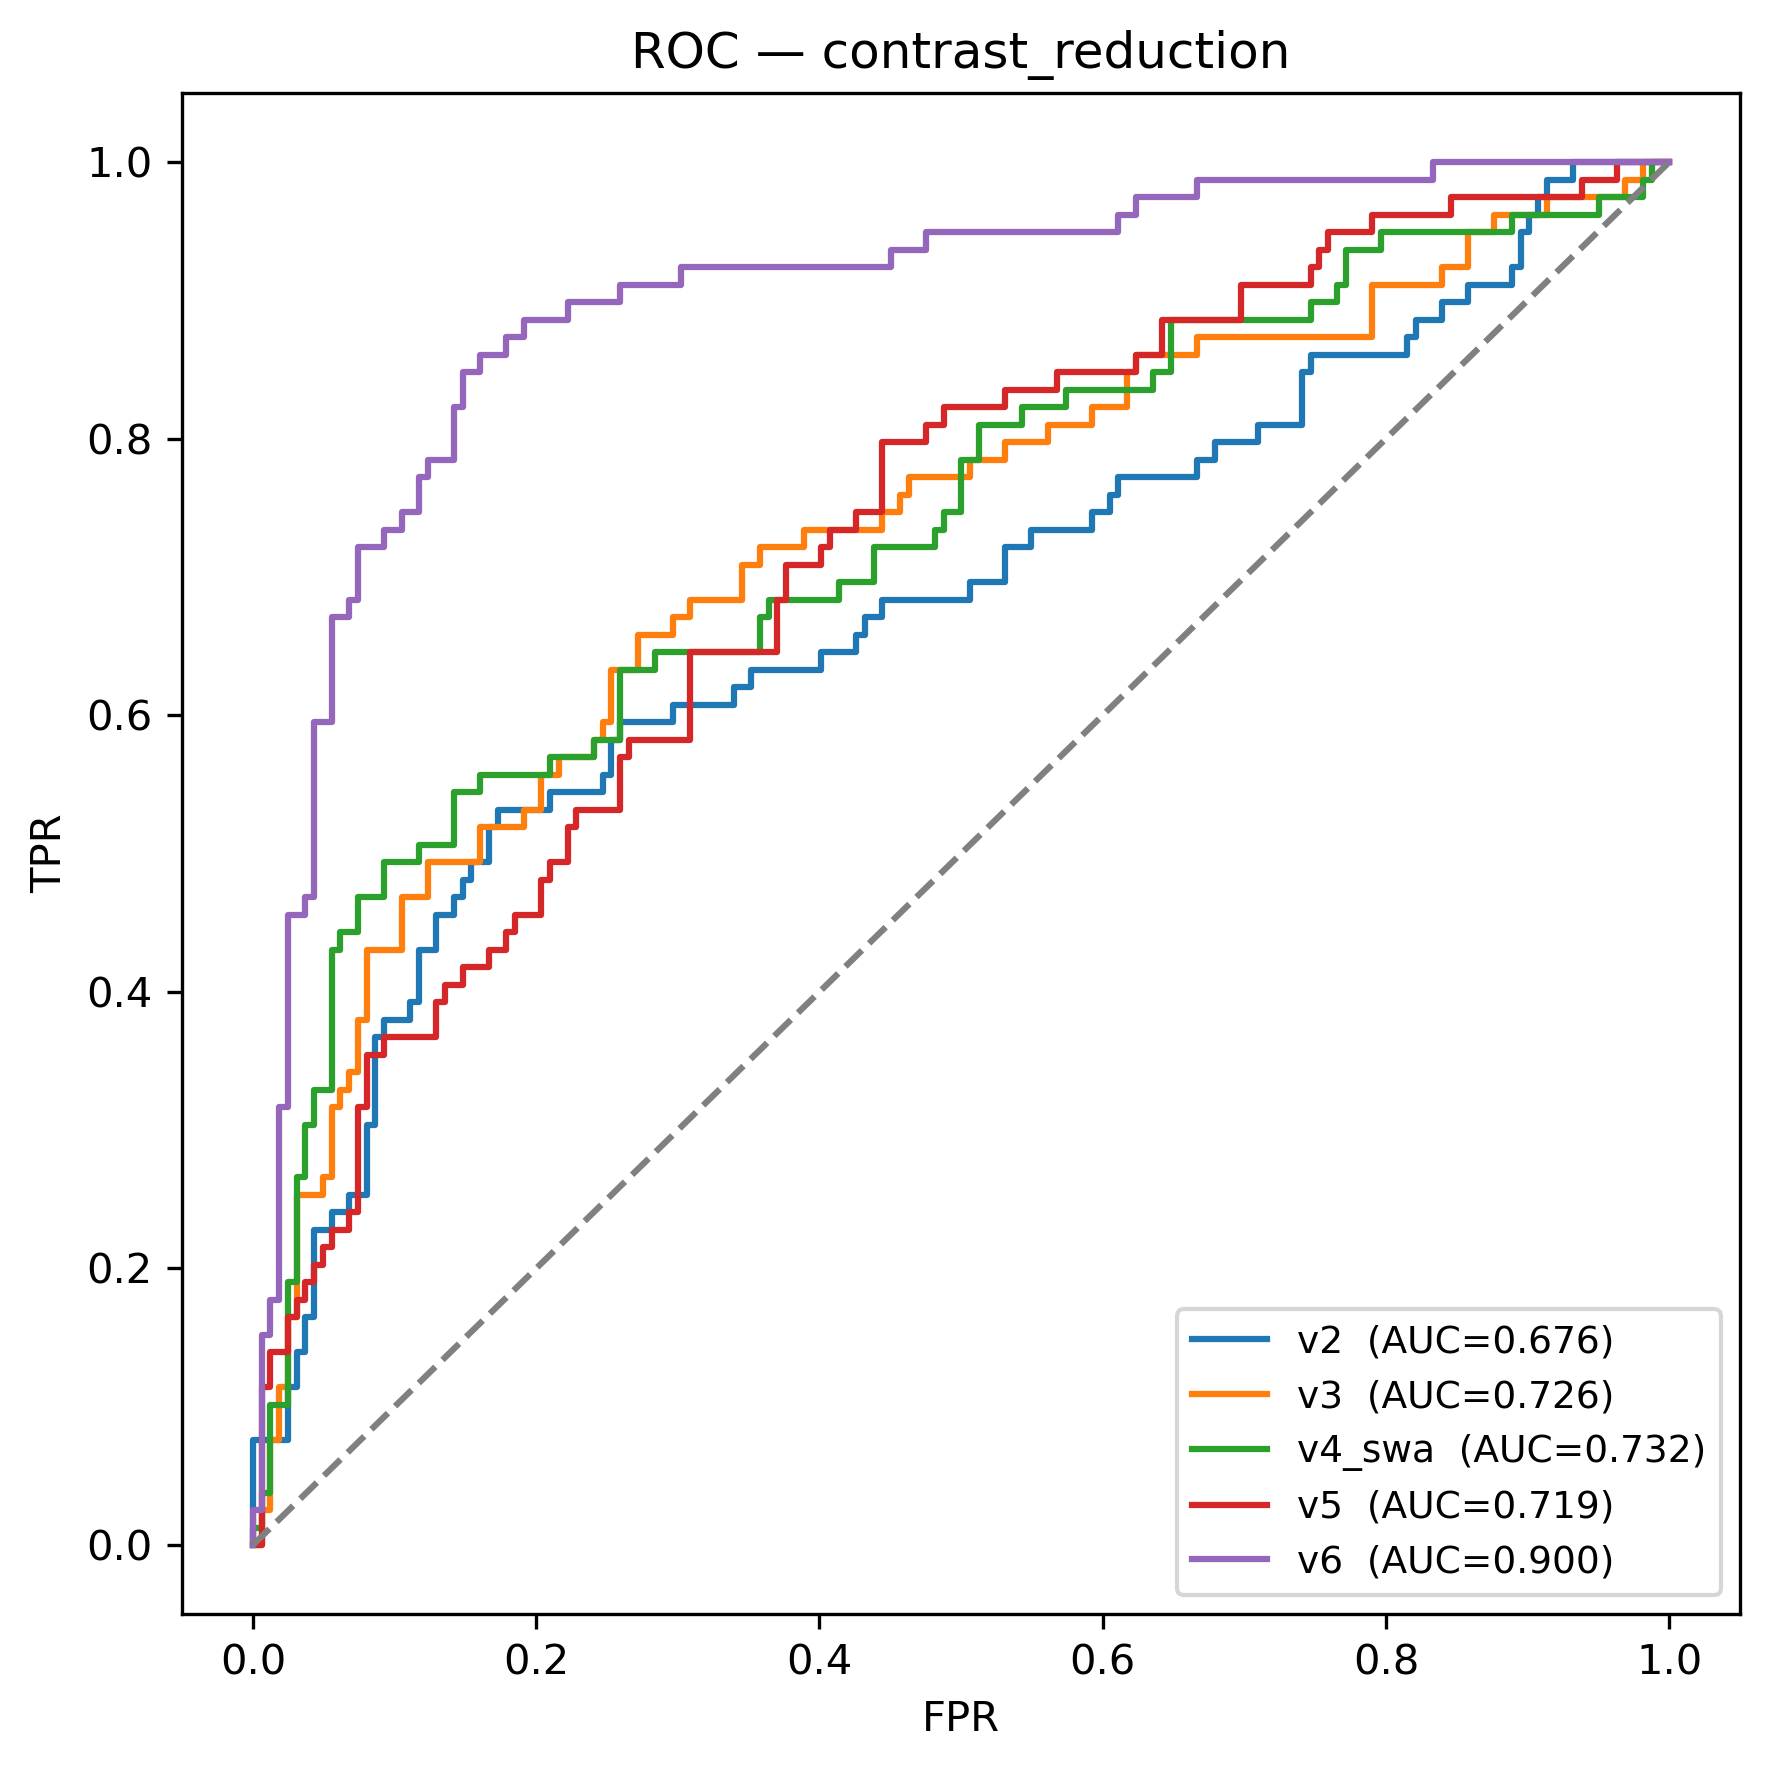

saved: /Users/yj/Library/Mobile Documents/com~apple~CloudDocs/01_Academics_UMN/2026_Spring/CSCI 5527/final_proj/results/distortion_roc_contrast_reduction.png


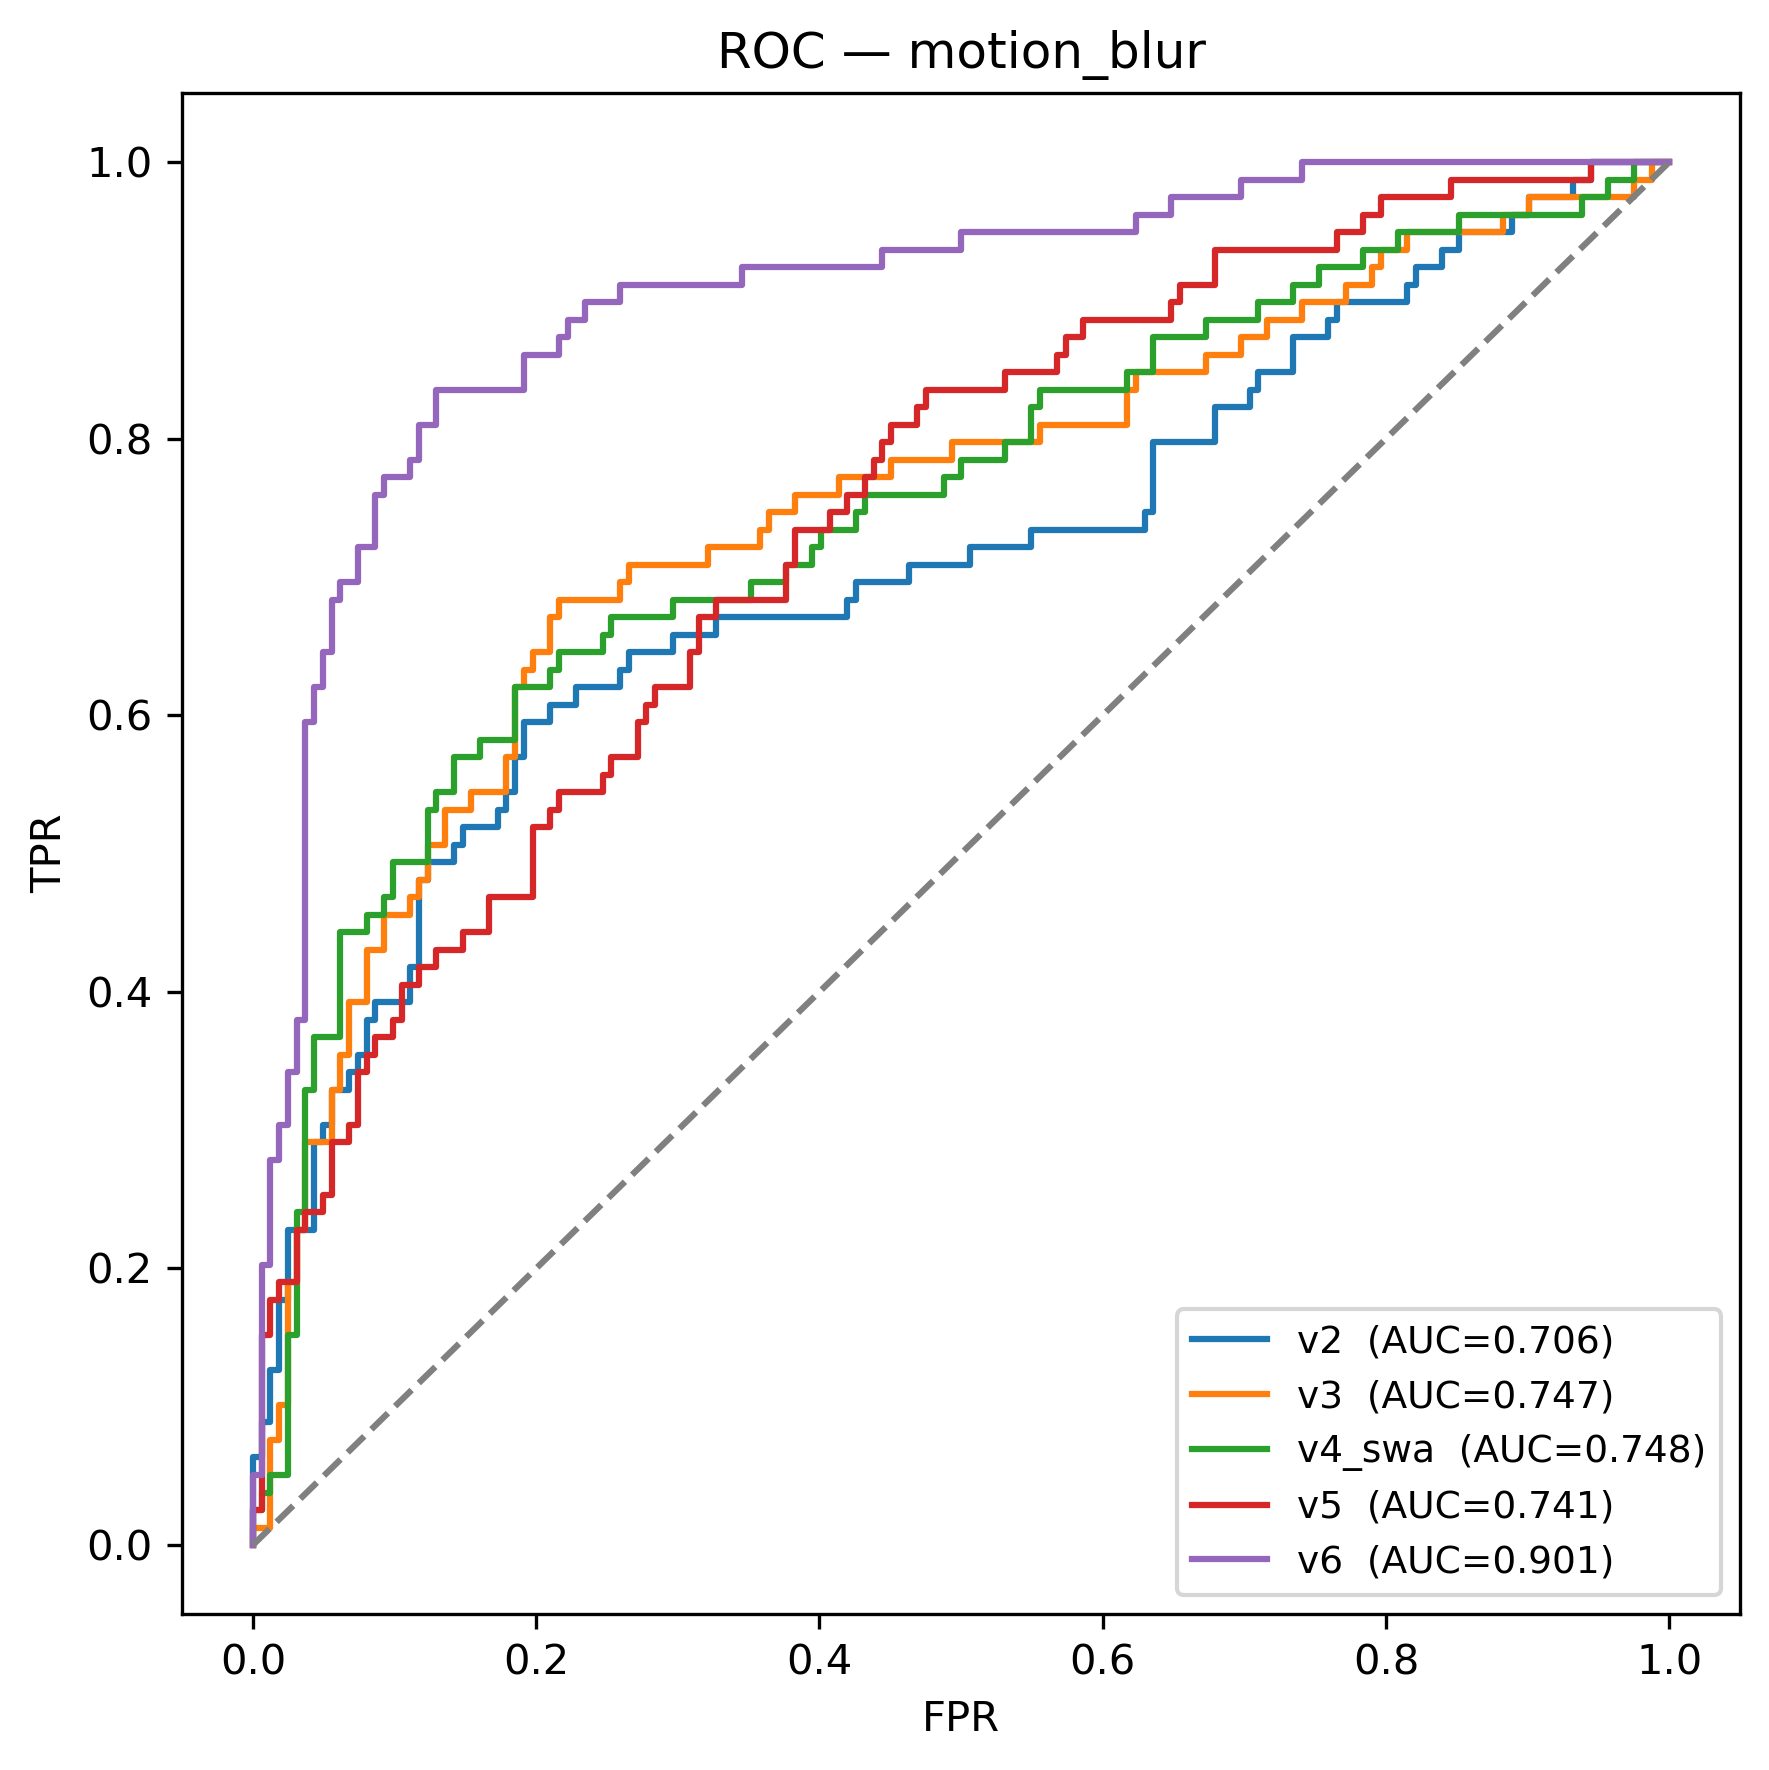

saved: /Users/yj/Library/Mobile Documents/com~apple~CloudDocs/01_Academics_UMN/2026_Spring/CSCI 5527/final_proj/results/distortion_roc_motion_blur.png


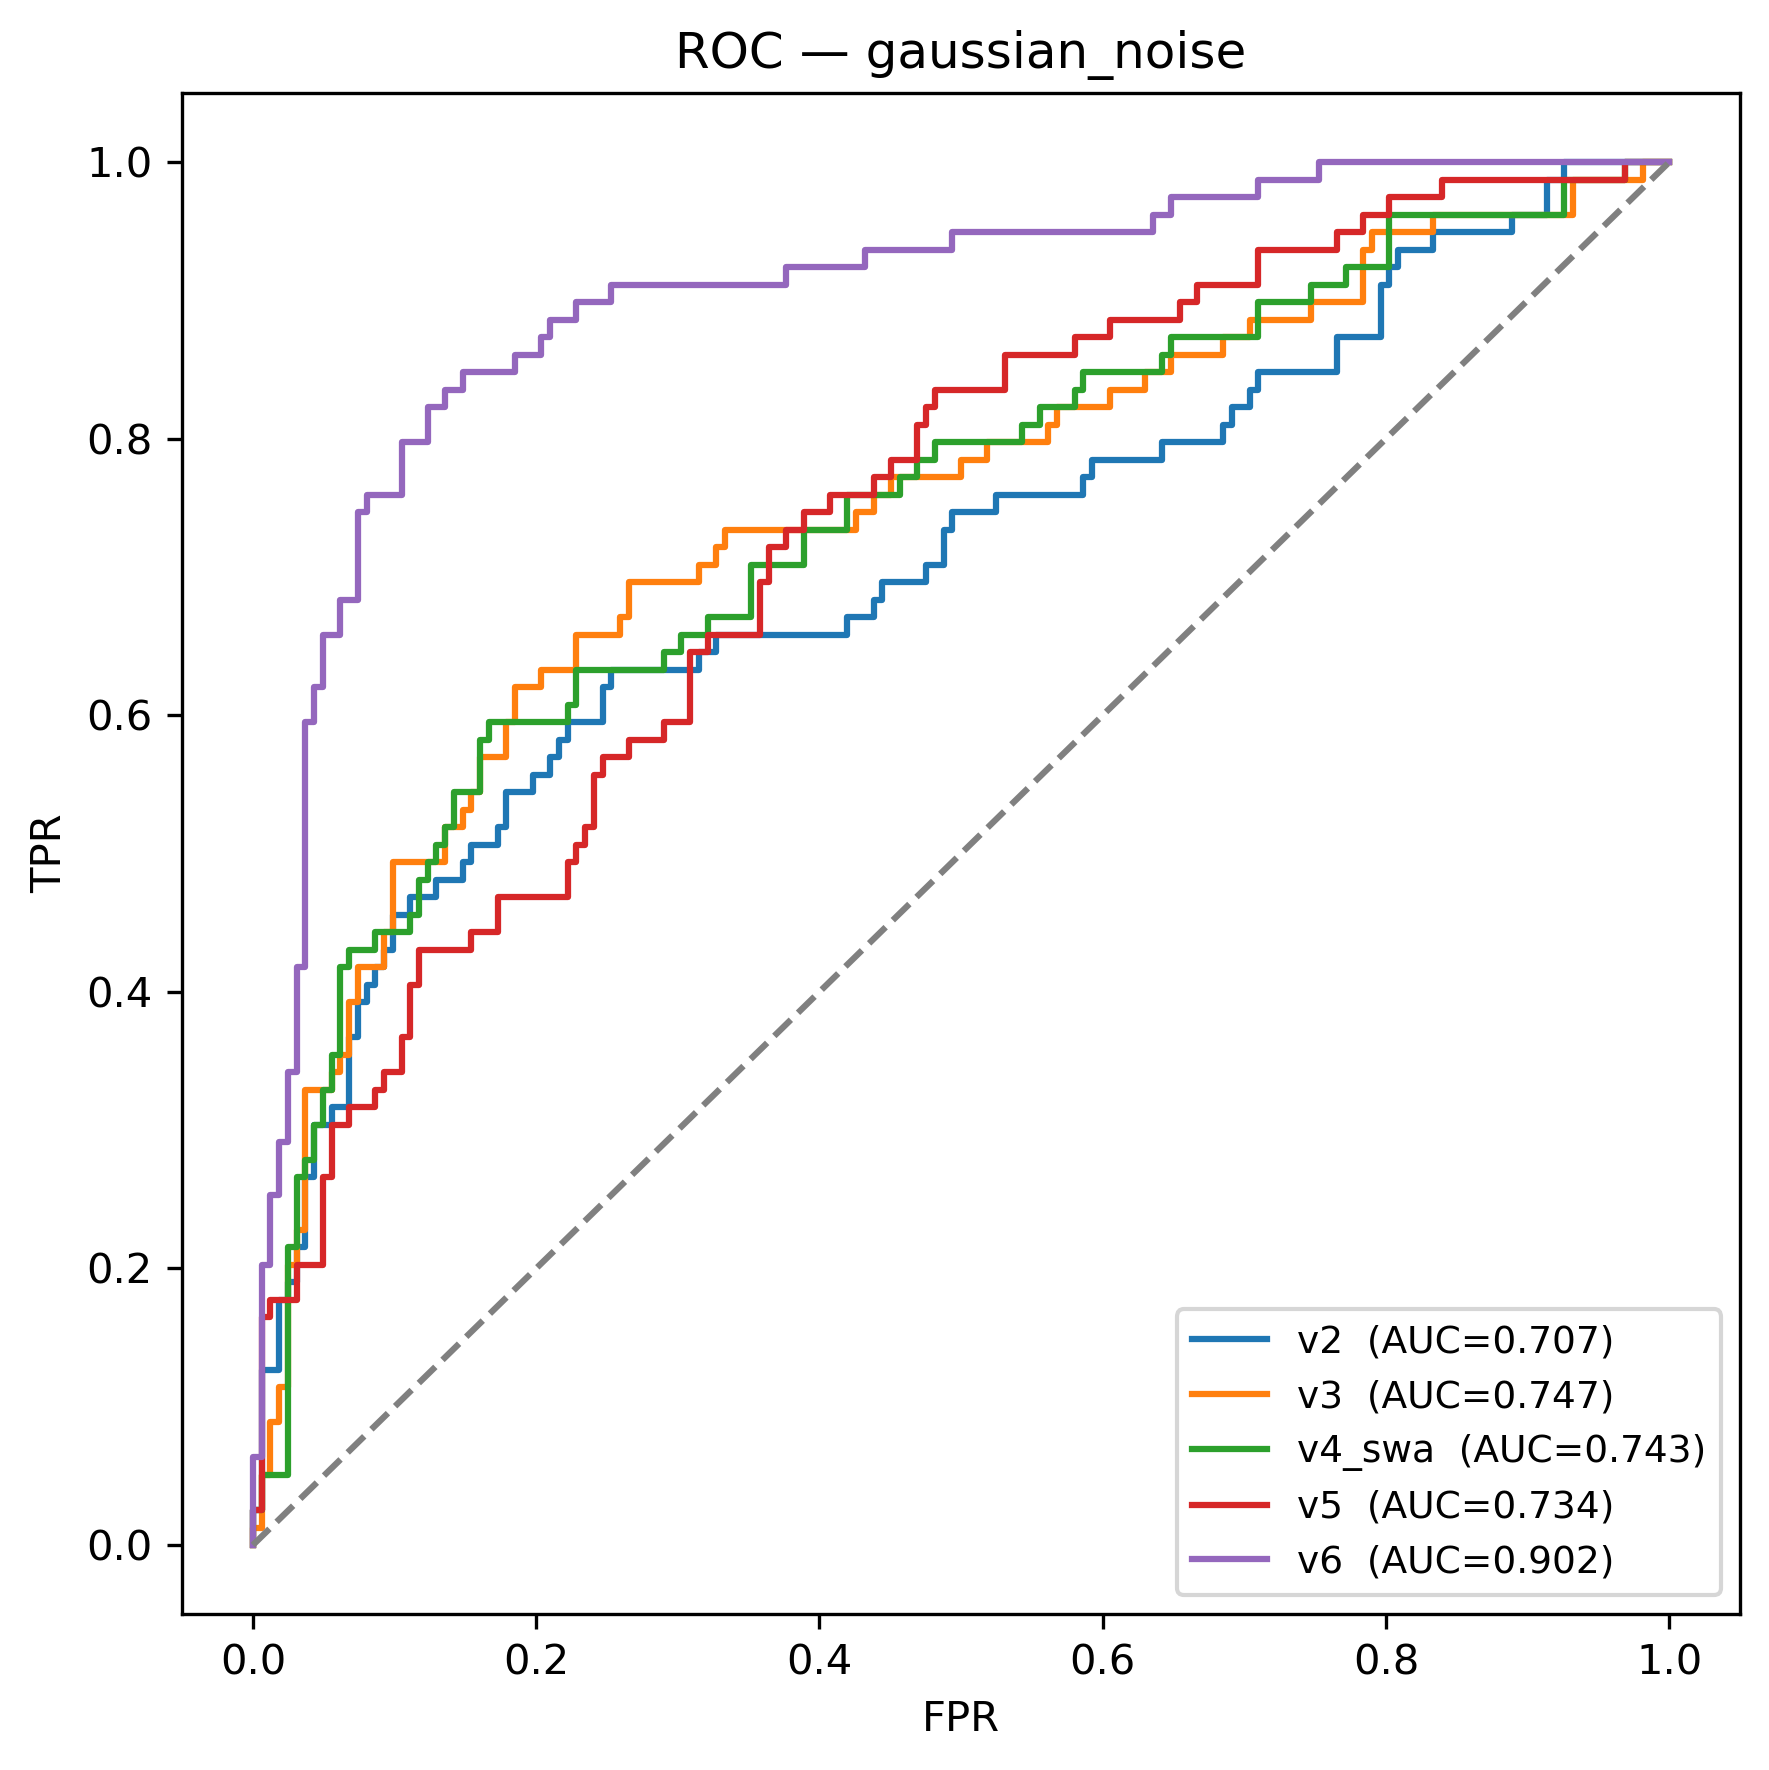

saved: /Users/yj/Library/Mobile Documents/com~apple~CloudDocs/01_Academics_UMN/2026_Spring/CSCI 5527/final_proj/results/distortion_roc_gaussian_noise.png


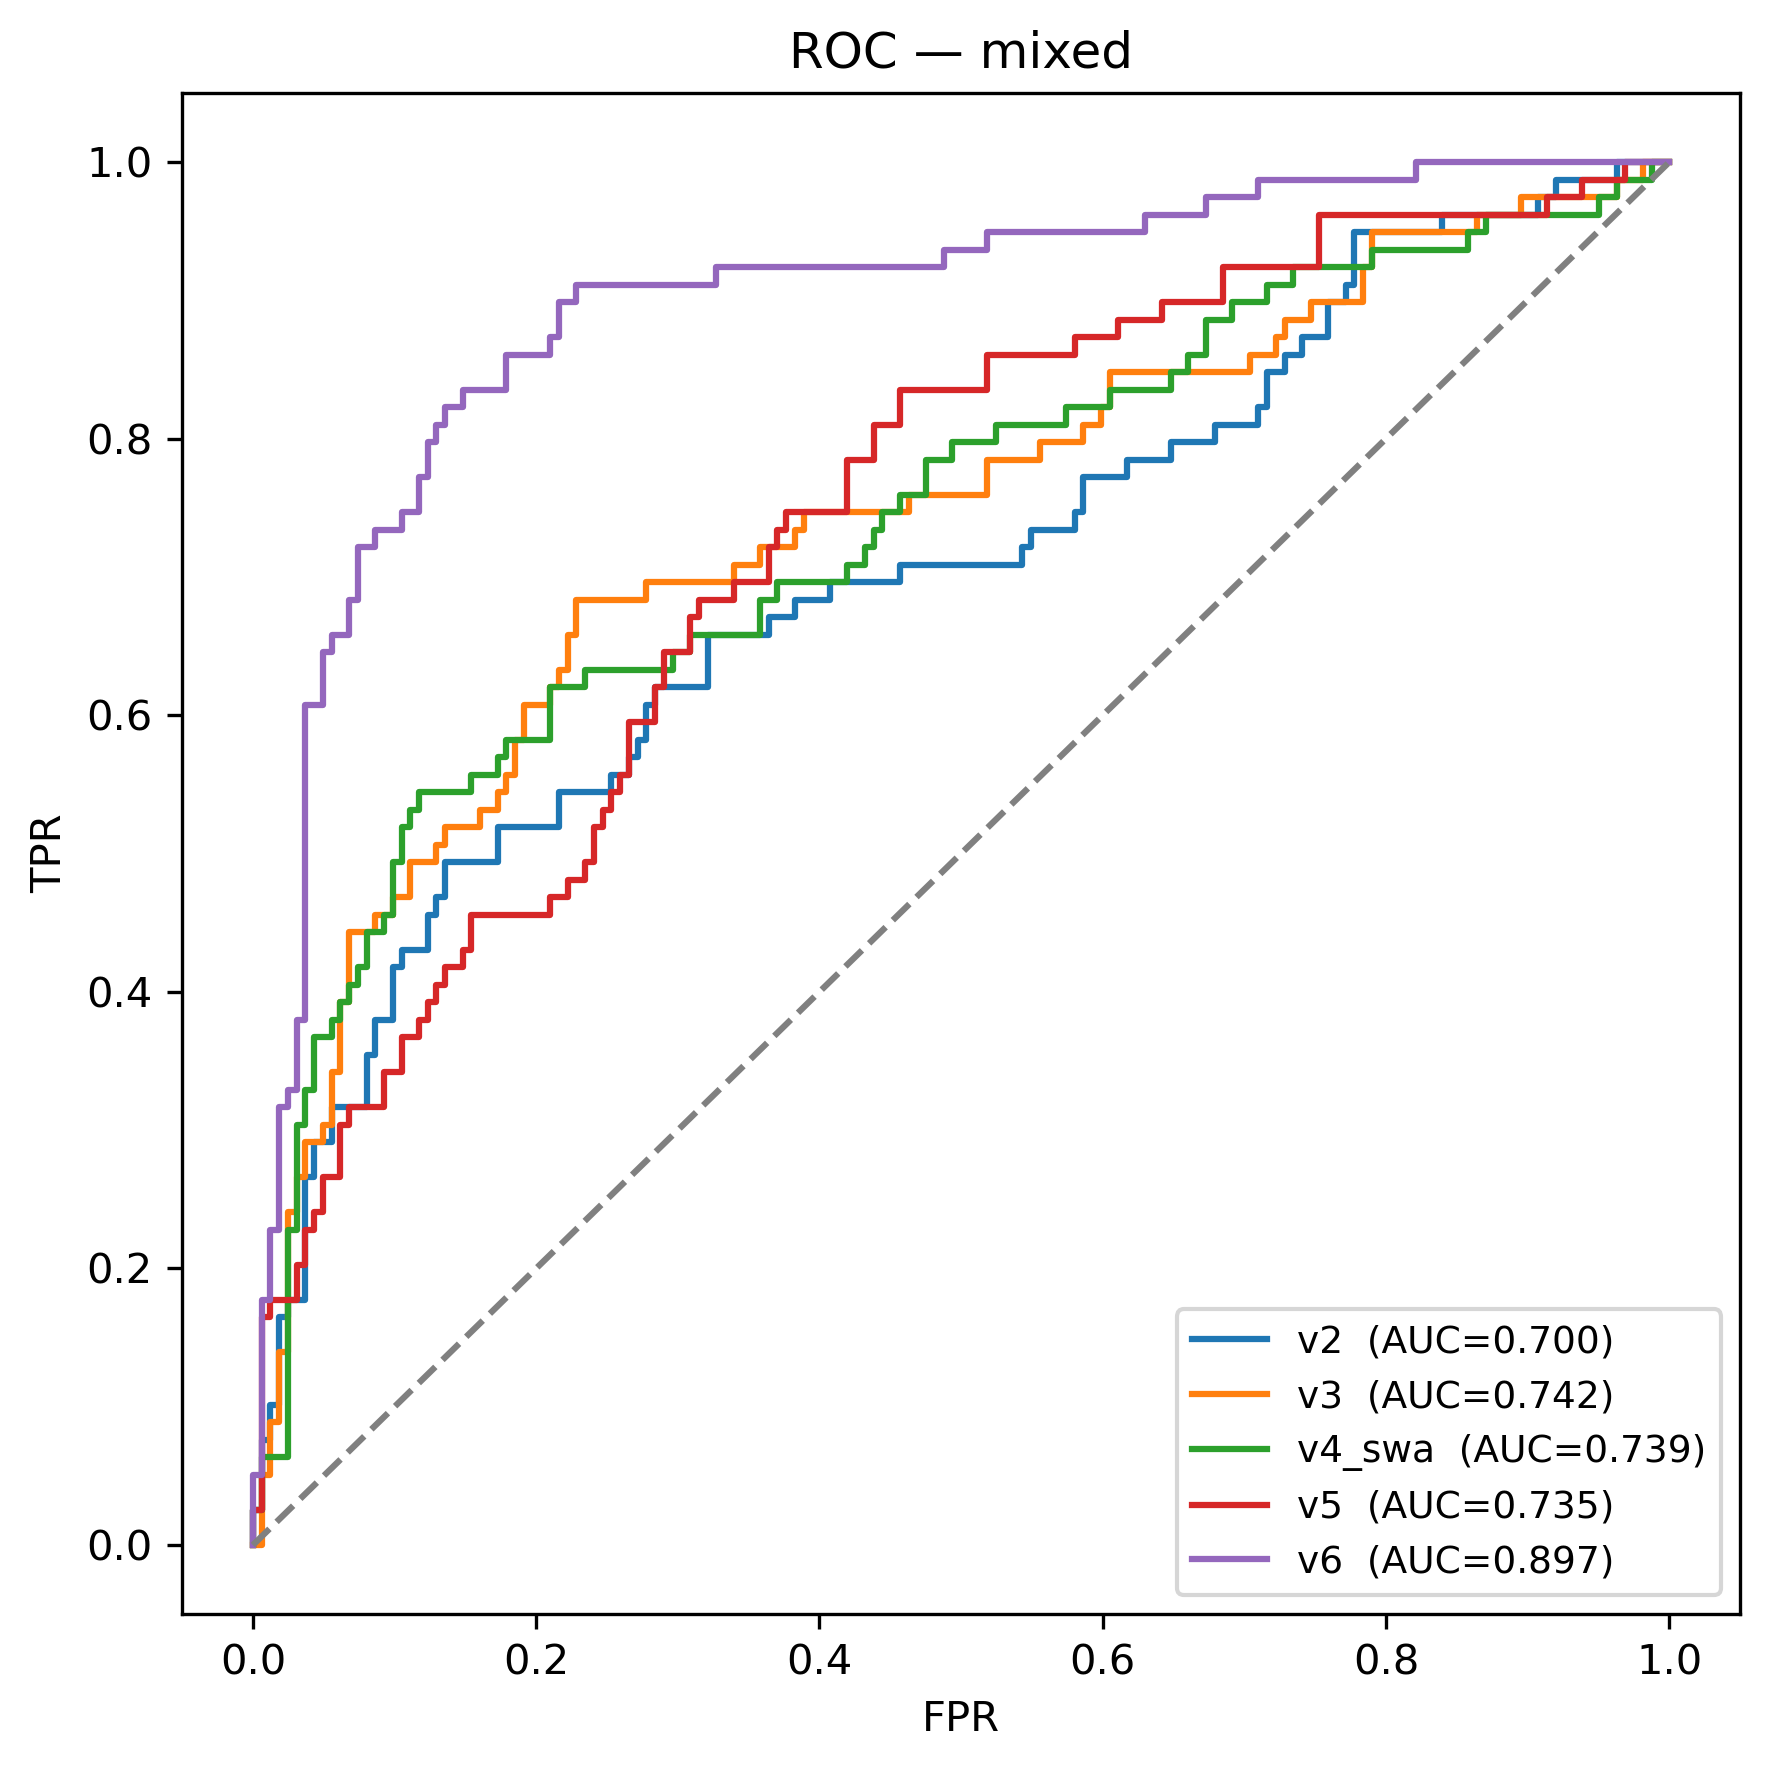

saved: /Users/yj/Library/Mobile Documents/com~apple~CloudDocs/01_Academics_UMN/2026_Spring/CSCI 5527/final_proj/results/distortion_roc_mixed.png


In [20]:
# ---- 13.3 ROC overlays per distortion (one figure per distortion) ----
for dlabel, _ in DISTORTIONS:
    fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
    for m in MODELS_ORDER:
        if (m, dlabel) not in predictions: continue
        p = predictions[(m, dlabel)]
        fpr, tpr, _ = roc_curve(y_test, p)
        a = roc_auc_score(y_test, p)
        ax.plot(fpr, tpr, label=f'{m}  (AUC={a:.3f})')
    ax.plot([0,1], [0,1], '--', color='gray')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'ROC — {dlabel}')
    ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    out = RES / f'distortion_roc_{dlabel}.png'
    plt.savefig(out, dpi=300); plt.show(); plt.close()
    print('saved:', out)

In [21]:
# ---- 13.4 Save the prediction probabilities for downstream analysis ----
rows = []
for (m, d), p in predictions.items():
    for j in range(len(p)):
        rows.append({'model':m, 'distortion':d,
                     'subject_id': int(test_df.iloc[j]['subject_id']),
                     'study_id':   int(test_df.iloc[j]['study_id']),
                     'y_true': float(y_test[j]),
                     'prob':   float(p[j])})
pred_df = pd.DataFrame(rows)
pred_df.to_csv(RES / 'distortion_eval_predictions.csv', index=False)
print('saved:', RES / 'distortion_eval_predictions.csv', '|', len(pred_df), 'rows')

saved: /Users/yj/Library/Mobile Documents/com~apple~CloudDocs/01_Academics_UMN/2026_Spring/CSCI 5527/final_proj/results/distortion_eval_predictions.csv | 6025 rows


## 14. Done

Files written under `results/`:
- `distortion_eval_long.csv`  — long format, one row per (model, distortion)
- `distortion_eval_wide.csv`  — AUROC matrix (rows=distortion, cols=model)
- `distortion_eval_predictions.csv` — per-sample probabilities for further analysis
- `distortion_bar_per_distortion.png`
- `distortion_degradation_curves.png`
- `distortion_roc_<distortion>.png` (5 files: clean + 4 distortions)

**Interpretation tip**: v2/v3/v4 are image+EHR only — image distortions hit them hardest. v6 fuses radiologist report text and EHR alongside the image, so its degradation should be much smaller — that's the value of multimodal fusion under sensor degradation.